# 00 · Preparación de data
Convierte los archivos MTS a MP4 y recorta los clips por seña WH.

**Flujo:**
1. Convertir MTS → MP4
2. Explorar los videos (duración, fps, resolución)
3. Recortar clips por timestamp
4. Verificación visual

## Setup

In [1]:
# Verificar que ffmpeg está instalado
import subprocess
result = subprocess.run(['ffmpeg', '-version'], capture_output=True, text=True)
print(result.stdout.split('\n')[0])

# Si no está instalado:
# Mac:     brew install ffmpeg
# Ubuntu:  sudo apt install ffmpeg
# Windows: https://ffmpeg.org/download.html

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers


In [2]:
import subprocess
import pandas as pd
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Rutas base — ajusta si tu estructura es diferente
RAW_DIR   = Path('./data/raw_videos')       # donde están los .MTS originales
MP4_DIR   = Path('./data/mp4')         # donde irán los .mp4 convertidos
CLIPS_DIR = Path('./data/clips')       # donde irán los clips recortados por seña
CSV_PATH = Path('./data/anotaciones.csv')  # tu Excel con timestamps

# Crear carpetas si no existen
MP4_DIR.mkdir(parents=True, exist_ok=True)
CLIPS_DIR.mkdir(parents=True, exist_ok=True)

print('Rutas configuradas:')
print(f'  Raw:   {RAW_DIR.resolve()}')
print(f'  MP4:   {MP4_DIR.resolve()}')
print(f'  Clips: {CLIPS_DIR.resolve()}')

Rutas configuradas:
  Raw:   /home/pierov/piero/projects/whqlsp-detector/notebooks/data/raw_videos
  MP4:   /home/pierov/piero/projects/whqlsp-detector/notebooks/data/mp4
  Clips: /home/pierov/piero/projects/whqlsp-detector/notebooks/data/clips


## Sección 1 — Convertir MTS → MP4

In [3]:
# Ver cuántos archivos MTS hay
mts_files = sorted(RAW_DIR.glob('*.MTS')) + sorted(RAW_DIR.glob('*.mts'))
print(f'Archivos MTS encontrados: {len(mts_files)}')
for f in mts_files:
    print(f'  {f.name}')

Archivos MTS encontrados: 12
  que1_01.MTS
  que1_02.MTS
  que1_03.MTS
  que1_04.MTS
  que1_05.MTS
  que1_06.MTS
  quien1_01.MTS
  quien1_02.MTS
  quien1_03.MTS
  quien1_04.MTS
  quien1_05.MTS
  quien1_06.MTS


In [4]:
def convertir_mts_a_mp4(mts_path: Path, output_dir: Path, forzar=False) -> Path:
    """
    Convierte un archivo MTS a MP4 usando ffmpeg.
    Usa -c copy (sin reencoding) → muy rápido, sin pérdida de calidad.
    Si el video tiene problemas de compatibilidad, cambia a -c:v libx264.
    """
    output_path = output_dir / (mts_path.stem + '.mp4')
    
    if output_path.exists() and not forzar:
        print(f'  Ya existe: {output_path.name} — saltando')
        return output_path
    
    cmd = [
        'ffmpeg',
        '-i', str(mts_path),
        '-c', 'copy',          # copia stream sin reencoding
        '-y',                  # sobreescribe sin preguntar
        str(output_path)
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f'  ERROR en {mts_path.name}:')
        print(result.stderr[-500:])  # últimas líneas del error
        return None
    
    print(f'  OK: {mts_path.name} → {output_path.name}')
    return output_path


print('Convirtiendo archivos MTS a MP4...\n')
mp4_convertidos = []

for mts in mts_files:
    resultado = convertir_mts_a_mp4(mts, MP4_DIR)
    if resultado:
        mp4_convertidos.append(resultado)

print(f'\nTotal convertidos: {len(mp4_convertidos)} / {len(mts_files)}')

Convirtiendo archivos MTS a MP4...

  OK: que1_01.MTS → que1_01.mp4
  OK: que1_02.MTS → que1_02.mp4
  OK: que1_03.MTS → que1_03.mp4
  OK: que1_04.MTS → que1_04.mp4
  OK: que1_05.MTS → que1_05.mp4
  OK: que1_06.MTS → que1_06.mp4
  OK: quien1_01.MTS → quien1_01.mp4
  OK: quien1_02.MTS → quien1_02.mp4
  OK: quien1_03.MTS → quien1_03.mp4
  OK: quien1_04.MTS → quien1_04.mp4
  OK: quien1_05.MTS → quien1_05.mp4
  OK: quien1_06.MTS → quien1_06.mp4

Total convertidos: 12 / 12


## Sección 2 — Explorar los videos

In [14]:
def info_video(path: Path) -> dict:
    """Extrae metadatos básicos de un video con OpenCV."""
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        return {'archivo': path.name, 'error': 'No se pudo abrir'}
    
    fps      = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    ancho    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duracion = n_frames / fps if fps > 0 else 0
    cap.release()
    
    return {
        'archivo':   path.name,
        'fps':       round(fps, 2),
        'frames':    n_frames,
        'duracion':  round(duracion, 2),
        'resolucion': f'{ancho}x{alto}',
    }


mp4_files = sorted(MP4_DIR.glob('*.mp4'))
infos = [info_video(f) for f in mp4_files]
df_videos = pd.DataFrame(infos)

print(f'Videos MP4 disponibles: {len(df_videos)}\n')
df_videos

Videos MP4 disponibles: 12



,archivo,fps,frames,duracion,resolucion
0,que1_01.mp4,59.94,20730,345.85,1920x1080
1,que1_02.mp4,59.94,14550,242.74,1920x1080
2,que1_03.mp4,59.94,5970,99.60,1920x1080
3,que1_04.mp4,59.94,8370,139.64,1920x1080
4,que1_05.mp4,59.94,24120,402.40,1920x1080
5,que1_06.mp4,59.94,28410,473.97,1920x1080
6,quien1_01.mp4,59.94,20730,345.85,1920x1080
7,quien1_02.mp4,59.94,11490,191.69,1920x1080
8,quien1_03.mp4,59.94,42930,716.22,1920x1080
9,quien1_04.mp4,59.94,17910,298.80,1920x1080


In [15]:
# Resumen rápido
if len(df_videos) > 0 and 'error' not in df_videos.columns:
    print('Resumen:')
    print(f"  Duración total:   {df_videos['duracion'].sum():.1f} segundos")
    print(f"  Duración promedio: {df_videos['duracion'].mean():.1f} segundos")
    print(f"  FPS más común:    {df_videos['fps'].mode()[0]}")
    print(f"  Resoluciones:     {df_videos['resolucion'].unique()}")

Resumen:
  Duración total:   3978.5 segundos
  Duración promedio: 331.5 segundos
  FPS más común:    59.94
  Resoluciones:     <StringArray>
['1920x1080']
Length: 1, dtype: str


## Sección 3 — Recortar clips por timestamp

Carga el Excel y genera un clip MP4 por cada fila.

**Formato esperado del Excel** (ajusta los nombres de columna abajo si son diferentes):

| video | seña | inicio_seg | fin_seg |
|---|---|---|---|
| video_01.mp4 | QUE_PALMA | 4.2 | 6.8 |

In [20]:
# --- AJUSTA ESTOS NOMBRES según tu Excel ---
COL_VIDEO   = 'video'        # columna con el nombre del archivo de video
COL_SENA    = 'sena'         # columna con la etiqueta de la seña
COL_INICIO  = 'inicio_seg'   # columna con el segundo de inicio

df = pd.read_csv(CSV_PATH)
print(f'Filas cargadas: {len(df)}')
print(f'Columnas: {list(df.columns)}')
df.head(10)

Filas cargadas: 12
Columnas: ['video', 'sena', 'inicio_seg']


,video,sena,inicio_seg
0,que1_01.MTS,QUE1,92.0
1,que1_02.MTS,QUE1,200.0
2,que1_03.MTS,QUE1,33.0
3,que1_04.MTS,QUE1,57.0
4,que1_05.MTS,QUE1,147.0
5,que1_06.MTS,QUE1,307.0
6,quien1_01.MTS,QUIEN1,43.5
7,quien1_02.MTS,QUIEN1,69.5
8,quien1_03.MTS,QUIEN1,39.5
9,quien1_04.MTS,QUIEN1,79.5


In [21]:
# Contar ejemplos por seña antes de recortar
print('Ejemplos por seña:')
print(df[COL_SENA].value_counts().to_string())

Ejemplos por seña:
sena
QUE1      6
QUIEN1    6


In [22]:
def recortar_clip(video_path: Path, inicio: float, fin: float, output_path: Path) -> bool:
    """
    Recorta un segmento de video usando ffmpeg.
    Usa -c copy cuando es posible para no reencoder.
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    if output_path.exists():
        return True  # ya existe, saltar
    
    duracion = fin - inicio
    
    cmd = [
        'ffmpeg',
        '-ss', str(inicio),          # seek al inicio (antes de -i = más rápido)
        '-i', str(video_path),
        '-t', str(duracion),         # duración del clip
        '-c', 'copy',
        '-avoid_negative_ts', '1',
        '-y',
        str(output_path)
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    return result.returncode == 0

In [25]:
# Recortar todos los clips
errores = []
total = len(df)
offset = 2

for i, fila in df.iterrows():

    nombre_video = fila[COL_VIDEO]
    sena         = str(fila[COL_SENA]).strip().upper().replace(' ', '_')
    inicio       = float(fila[COL_INICIO]) - offset
    fin          = float(fila[COL_INICIO]) + offset
    
    # Buscar el video en la carpeta mp4
    video_path = MP4_DIR / nombre_video
    if not video_path.exists():
        # Intentar sin extensión o con variaciones
        stem = Path(nombre_video).stem
        video_path = MP4_DIR / f'{stem}.mp4'
    
    if not video_path.exists():
        errores.append(f'Fila {i}: no se encontró {nombre_video}')
        continue
    
    # Nombre del clip: seña_001.mp4, seña_002.mp4, etc.
    clips_de_esta_sena = list((CLIPS_DIR / sena).glob('*.mp4'))
    idx = len(clips_de_esta_sena) + 1
    output_path = CLIPS_DIR / sena / f'{sena.lower()}_{idx:03d}.mp4'
    
    ok = recortar_clip(video_path, inicio, fin, output_path)
    estado = 'OK' if ok else 'ERROR'
    print(f'[{i+1:3d}/{total}] {estado} | {sena} | {inicio}s → {fin}s')
    
    if not ok:
        errores.append(f'Fila {i}: error al recortar {nombre_video} ({inicio}→{fin})')

print(f'\nListo. Errores: {len(errores)}')
for e in errores:
    print(f'  {e}')

[  1/12] OK | QUE1 | 90.0s → 94.0s
[  2/12] OK | QUE1 | 198.0s → 202.0s
[  3/12] OK | QUE1 | 31.0s → 35.0s
[  4/12] OK | QUE1 | 55.0s → 59.0s
[  5/12] OK | QUE1 | 145.0s → 149.0s
[  6/12] OK | QUE1 | 305.0s → 309.0s
[  7/12] OK | QUIEN1 | 41.5s → 45.5s
[  8/12] OK | QUIEN1 | 67.5s → 71.5s
[  9/12] OK | QUIEN1 | 37.5s → 41.5s
[ 10/12] OK | QUIEN1 | 77.5s → 81.5s
[ 11/12] OK | QUIEN1 | 103.5s → 107.5s
[ 12/12] OK | QUIEN1 | 50.5s → 54.5s

Listo. Errores: 0


In [11]:
# Resumen de clips generados
print('Clips generados por seña:\n')
total_clips = 0
for carpeta in sorted(CLIPS_DIR.iterdir()):
    if carpeta.is_dir():
        clips = list(carpeta.glob('*.mp4'))
        print(f'  {carpeta.name:<20} {len(clips):>3} clips')
        total_clips += len(clips)
print(f'  {"TOTAL":<20} {total_clips:>3} clips')

Clips generados por seña:

  QUE1                   6 clips
  QUIEN1                 5 clips
  TOTAL                 11 clips


## Sección 4 — Verificación visual
Muestra el primer frame de un clip de cada seña para confirmar que el recorte quedó bien.

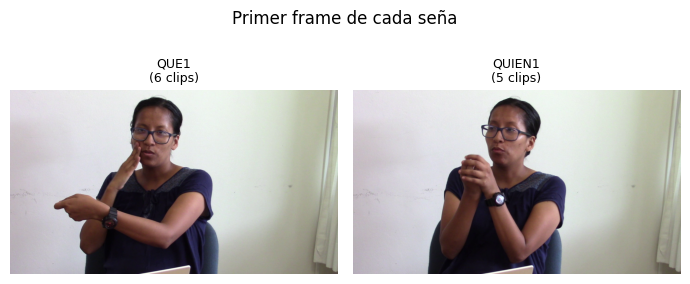

Imagen guardada en data/verificacion_clips.png


In [12]:
def primer_frame(clip_path: Path):
    """Extrae el primer frame de un video como imagen RGB."""
    cap = cv2.VideoCapture(str(clip_path))
    ok, frame = cap.read()
    cap.release()
    if ok:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return None


carpetas = sorted([c for c in CLIPS_DIR.iterdir() if c.is_dir()])
n = len(carpetas)

if n == 0:
    print('No hay clips aún. Ejecuta primero la Sección 3.')
else:
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3))
    axes = [axes] if n == 1 else axes.flatten()
    
    for ax, carpeta in zip(axes, carpetas):
        clips = sorted(carpeta.glob('*.mp4'))
        if clips:
            frame = primer_frame(clips[0])
            if frame is not None:
                ax.imshow(frame)
                ax.set_title(f'{carpeta.name}\n({len(clips)} clips)', fontsize=9)
            else:
                ax.set_title(f'{carpeta.name}\n(frame no leído)', fontsize=9)
        ax.axis('off')
    
    # Ocultar ejes sobrantes
    for ax in axes[n:]:
        ax.set_visible(False)
    
    plt.suptitle('Primer frame de cada seña', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('../data/verificacion_clips.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Imagen guardada en data/verificacion_clips.png')

In [13]:
# Verificar duración de los clips generados
# Idealmente todos deberían estar entre 1 y 5 segundos
print('Duración de clips por seña:\n')

for carpeta in sorted(CLIPS_DIR.iterdir()):
    if not carpeta.is_dir():
        continue
    clips = sorted(carpeta.glob('*.mp4'))
    if not clips:
        continue
    
    duraciones = []
    for clip in clips:
        cap = cv2.VideoCapture(str(clip))
        fps = cap.get(cv2.CAP_PROP_FPS)
        frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        cap.release()
        if fps > 0:
            duraciones.append(frames / fps)
    
    if duraciones:
        print(f'  {carpeta.name:<20} '
              f'min={min(duraciones):.1f}s  '
              f'max={max(duraciones):.1f}s  '
              f'prom={sum(duraciones)/len(duraciones):.1f}s')

Duración de clips por seña:

  QUE1                 min=4.2s  max=4.5s  prom=4.4s
  QUIEN1               min=4.4s  max=4.5s  prom=4.5s


---
## ¿Qué sigue?

Si los clips se ven bien en la verificación visual, el siguiente notebook es:

**`01_extraer_landmarks.ipynb`** — corre MediaPipe Hands sobre cada clip y guarda los landmarks como `.npy`